In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
#Pull in the libraries we need to read and print json files from the internet
import json
import requests
import pandas as pd
import numpy as np

from pprint import pprint

In [3]:
info = pd.read_csv("/content/drive/MyDrive/CSCI 413/Semester project/athlete_information.csv")
results = pd.read_csv("/content/drive/MyDrive/CSCI 413/Semester project/athlete_results.csv")

In [4]:
results_info = pd.merge(results, info, on='athlete_id', how='inner')

In [5]:
results_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135444 entries, 0 to 135443
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   athlete_id                135444 non-null  int64  
 1   rank                      135444 non-null  int64  
 2   discipline                135444 non-null  object 
 3   season                    135444 non-null  int64  
 4   date                      135444 non-null  object 
 5   event_id                  135444 non-null  int64  
 6   event_location            134646 non-null  object 
 7   d_cat                     135444 non-null  int64  
 8   firstname                 135444 non-null  object 
 9   lastname                  135444 non-null  object 
 10  age                       93314 non-null   float64
 11  gender                    135444 non-null  object 
 12  country                   135444 non-null  object 
 13  height                    26332 non-null   f

In [6]:
results_info.drop(["height", "arm_span"], axis = 1, inplace = True)

In [7]:

newresults_info =results_info[results_info.isnull().any(axis=1)]


In [8]:
pararesults_info = results_info.drop(newresults_info.index, axis = 0)

In [9]:
newresults_info.drop(["paraclimbing_sport_class"], axis = 1, inplace = True)

/tmp/ipython-input-2417874045.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  newresults_info.drop(["paraclimbing_sport_class"], axis = 1, inplace = True)


In [10]:
newresults_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 133007 entries, 37 to 135443
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   athlete_id      133007 non-null  int64  
 1   rank            133007 non-null  int64  
 2   discipline      133007 non-null  object 
 3   season          133007 non-null  int64  
 4   date            133007 non-null  object 
 5   event_id        133007 non-null  int64  
 6   event_location  132209 non-null  object 
 7   d_cat           133007 non-null  int64  
 8   firstname       133007 non-null  object 
 9   lastname        133007 non-null  object 
 10  age             90877 non-null   float64
 11  gender          133007 non-null  object 
 12  country         133007 non-null  object 
 13  birthday        90877 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 15.2+ MB


In [11]:
pararesults_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2437 entries, 0 to 135127
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   athlete_id                2437 non-null   int64  
 1   rank                      2437 non-null   int64  
 2   discipline                2437 non-null   object 
 3   season                    2437 non-null   int64  
 4   date                      2437 non-null   object 
 5   event_id                  2437 non-null   int64  
 6   event_location            2437 non-null   object 
 7   d_cat                     2437 non-null   int64  
 8   firstname                 2437 non-null   object 
 9   lastname                  2437 non-null   object 
 10  age                       2437 non-null   float64
 11  gender                    2437 non-null   object 
 12  country                   2437 non-null   object 
 13  paraclimbing_sport_class  2437 non-null   object 
 14  birthday   

In [12]:
newresults_info.drop(['firstname', 'lastname'], axis =1, inplace = True)

/tmp/ipython-input-915817578.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  newresults_info.drop(['firstname', 'lastname'], axis =1, inplace = True)


In [13]:
newresults_info= pd.get_dummies(newresults_info, columns = ['discipline','gender'])

In [14]:
newresults_info = newresults_info[~newresults_info['discipline_combined']]
newresults_info = newresults_info[~newresults_info['discipline_speed']]
newresults_info = newresults_info[~newresults_info['discipline_boulder&lead']]


In [15]:
newresults_info = newresults_info[~newresults_info['event_location'].str.contains('paraclimbing', case=False, na=False)]
newresults_info = newresults_info[~newresults_info['event_location'].str.contains('pc', case=False, na=False)]


In [16]:
newresults_info.drop(['discipline_combined'], axis =1, inplace= True)
newresults_info.drop(['discipline_speed'], axis =1, inplace= True)
newresults_info.drop(['discipline_boulder&lead'], axis =1, inplace= True)


In [17]:
newresults_info['birthday'] = pd.to_datetime(newresults_info['birthday'], errors='coerce')
newresults_info['date'] = pd.to_datetime(newresults_info['date'], errors='coerce')


newresults_info['age_at_comp'] = (newresults_info['date'] - newresults_info['birthday']).dt.days / 365.25

In [18]:
newresults_info.drop(["age", 'birthday'], axis = 1, inplace = True)

In [19]:
median_age = newresults_info['age_at_comp'].median()+5
missing_mask = newresults_info['age_at_comp'].isna()
newresults_info.loc[missing_mask, 'age_at_comp'] = median_age + np.random.normal(0, 5, size=missing_mask.sum())

In [20]:
newresults_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 105357 entries, 41 to 135443
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   athlete_id          105357 non-null  int64         
 1   rank                105357 non-null  int64         
 2   season              105357 non-null  int64         
 3   date                105357 non-null  datetime64[ns]
 4   event_id            105357 non-null  int64         
 5   event_location      104847 non-null  object        
 6   d_cat               105357 non-null  int64         
 7   country             105357 non-null  object        
 8   discipline_boulder  105357 non-null  bool          
 9   discipline_lead     105357 non-null  bool          
 10  gender_female       105357 non-null  bool          
 11  gender_male         105357 non-null  bool          
 12  age_at_comp         105357 non-null  float64       
dtypes: bool(4), datetime64[ns](1), fl

In [21]:
newresults_info['date'] = pd.to_datetime(newresults_info['date'], errors='coerce')

In [22]:
newresults_info['adult'] = np.where(newresults_info['age_at_comp'] >= 19, True, False)

In [23]:
newresults_info.drop(['event_location'], axis=1, inplace= True)

In [24]:
newresults_info = newresults_info[newresults_info['rank'] > 0]
newresults_info = newresults_info[newresults_info['rank'] <= 200]

newresults_info = newresults_info[newresults_info['age_at_comp'] > 10]

In [25]:
country_counts = newresults_info['country'].value_counts()
newresults_info['country_encoded'] = newresults_info['country'].map(country_counts)
newresults_info.drop(['country'], axis =1, inplace= True)


### Exploratory Data Analysis (EDA)

In [26]:
newresults_info.describe()

,athlete_id,rank,season,date,event_id,d_cat,age_at_comp,country_encoded
count,105206.000000,105206.000000,105206.000000,105206,105206.000000,105206.000000,105206.000000,105206.000000
mean,4926.970810,25.849229,2012.040910,2012-08-16 10:32:10.886071296,783.351121,126.225519,21.201362,4285.028287
min,1.000000,1.000000,1991.000000,1991-04-26 00:00:00,65.000000,1.000000,10.000785,1.000000
25%,1453.000000,10.000000,2006.000000,2006-05-28 00:00:00,432.000000,5.000000,17.130732,1608.000000
50%,4180.000000,21.000000,2014.000000,2014-05-17 00:00:00,853.000000,27.000000,20.260096,4174.000000
75%,6714.000000,36.000000,2019.000000,2019-05-05 00:00:00,1119.000000,241.000000,24.673511,6099.000000
max,16408.000000,152.000000,2024.000000,2024-10-06 00:00:00,1396.000000,615.000000,52.405202,10475.000000
std,4066.729907,20.774702,8.558488,NaN,389.882227,137.221555,5.118056,2931.290026


In [27]:
newresults_info.head()

,athlete_id,rank,season,date,event_id,d_cat,discipline_boulder,discipline_lead,gender_female,gender_male,age_at_comp,adult,country_encoded
41,33,42,1994,1994-07-28,141,393,False,True,False,True,23.077344,True,4965
42,33,48,1994,1994-04-29,135,1,False,True,False,True,22.830938,True,4965
43,33,27,1993,1993-11-05,129,1,False,True,False,True,22.351814,True,4965
44,33,21,1993,1993-07-22,132,393,False,True,False,True,22.061602,True,4965
45,33,33,1993,1993-05-28,127,1,False,True,False,True,21.911020,True,4965


In [28]:
import matplotlib.pyplot as plt

<BarContainer object of 60 artists>

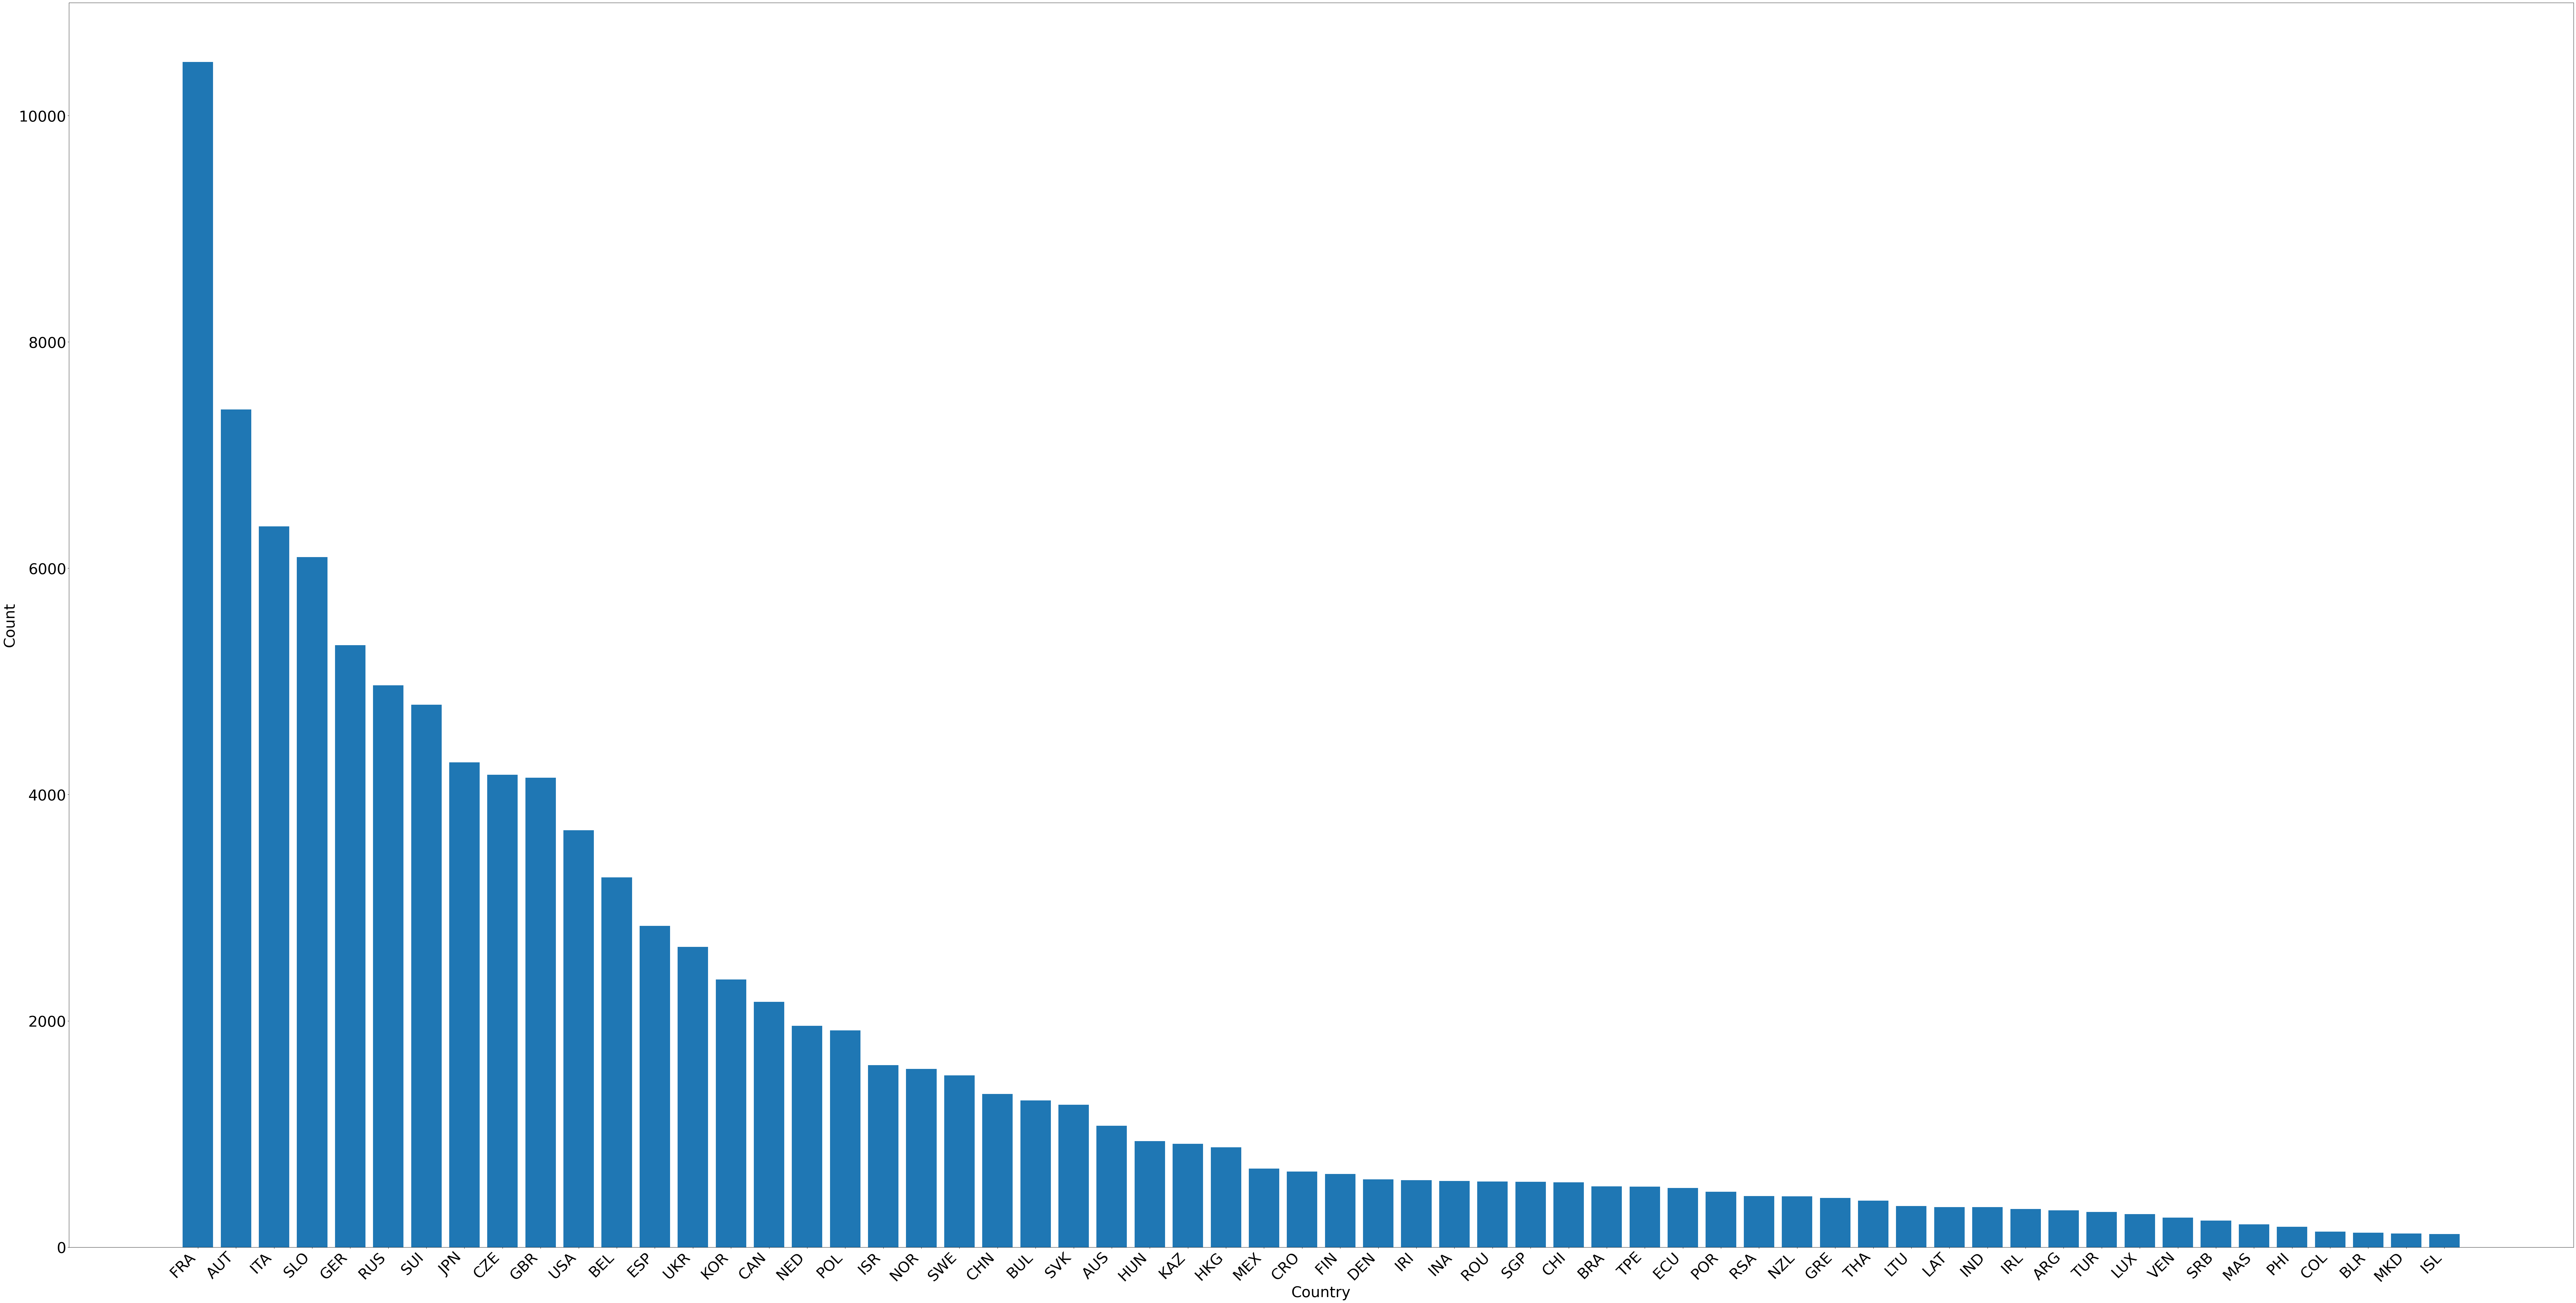

In [29]:
threshold = 100
filtered_counts = country_counts[country_counts >= threshold]
plt.figure(figsize=(120, 60))
plt.xlabel('Country', fontsize=40)
plt.ylabel('Count', fontsize=40)
plt.xticks(rotation=45, ha='right', fontsize=40)
plt.yticks(fontsize=40)
plt.bar(filtered_counts.index, filtered_counts.values)

<BarContainer object of 143 artists>

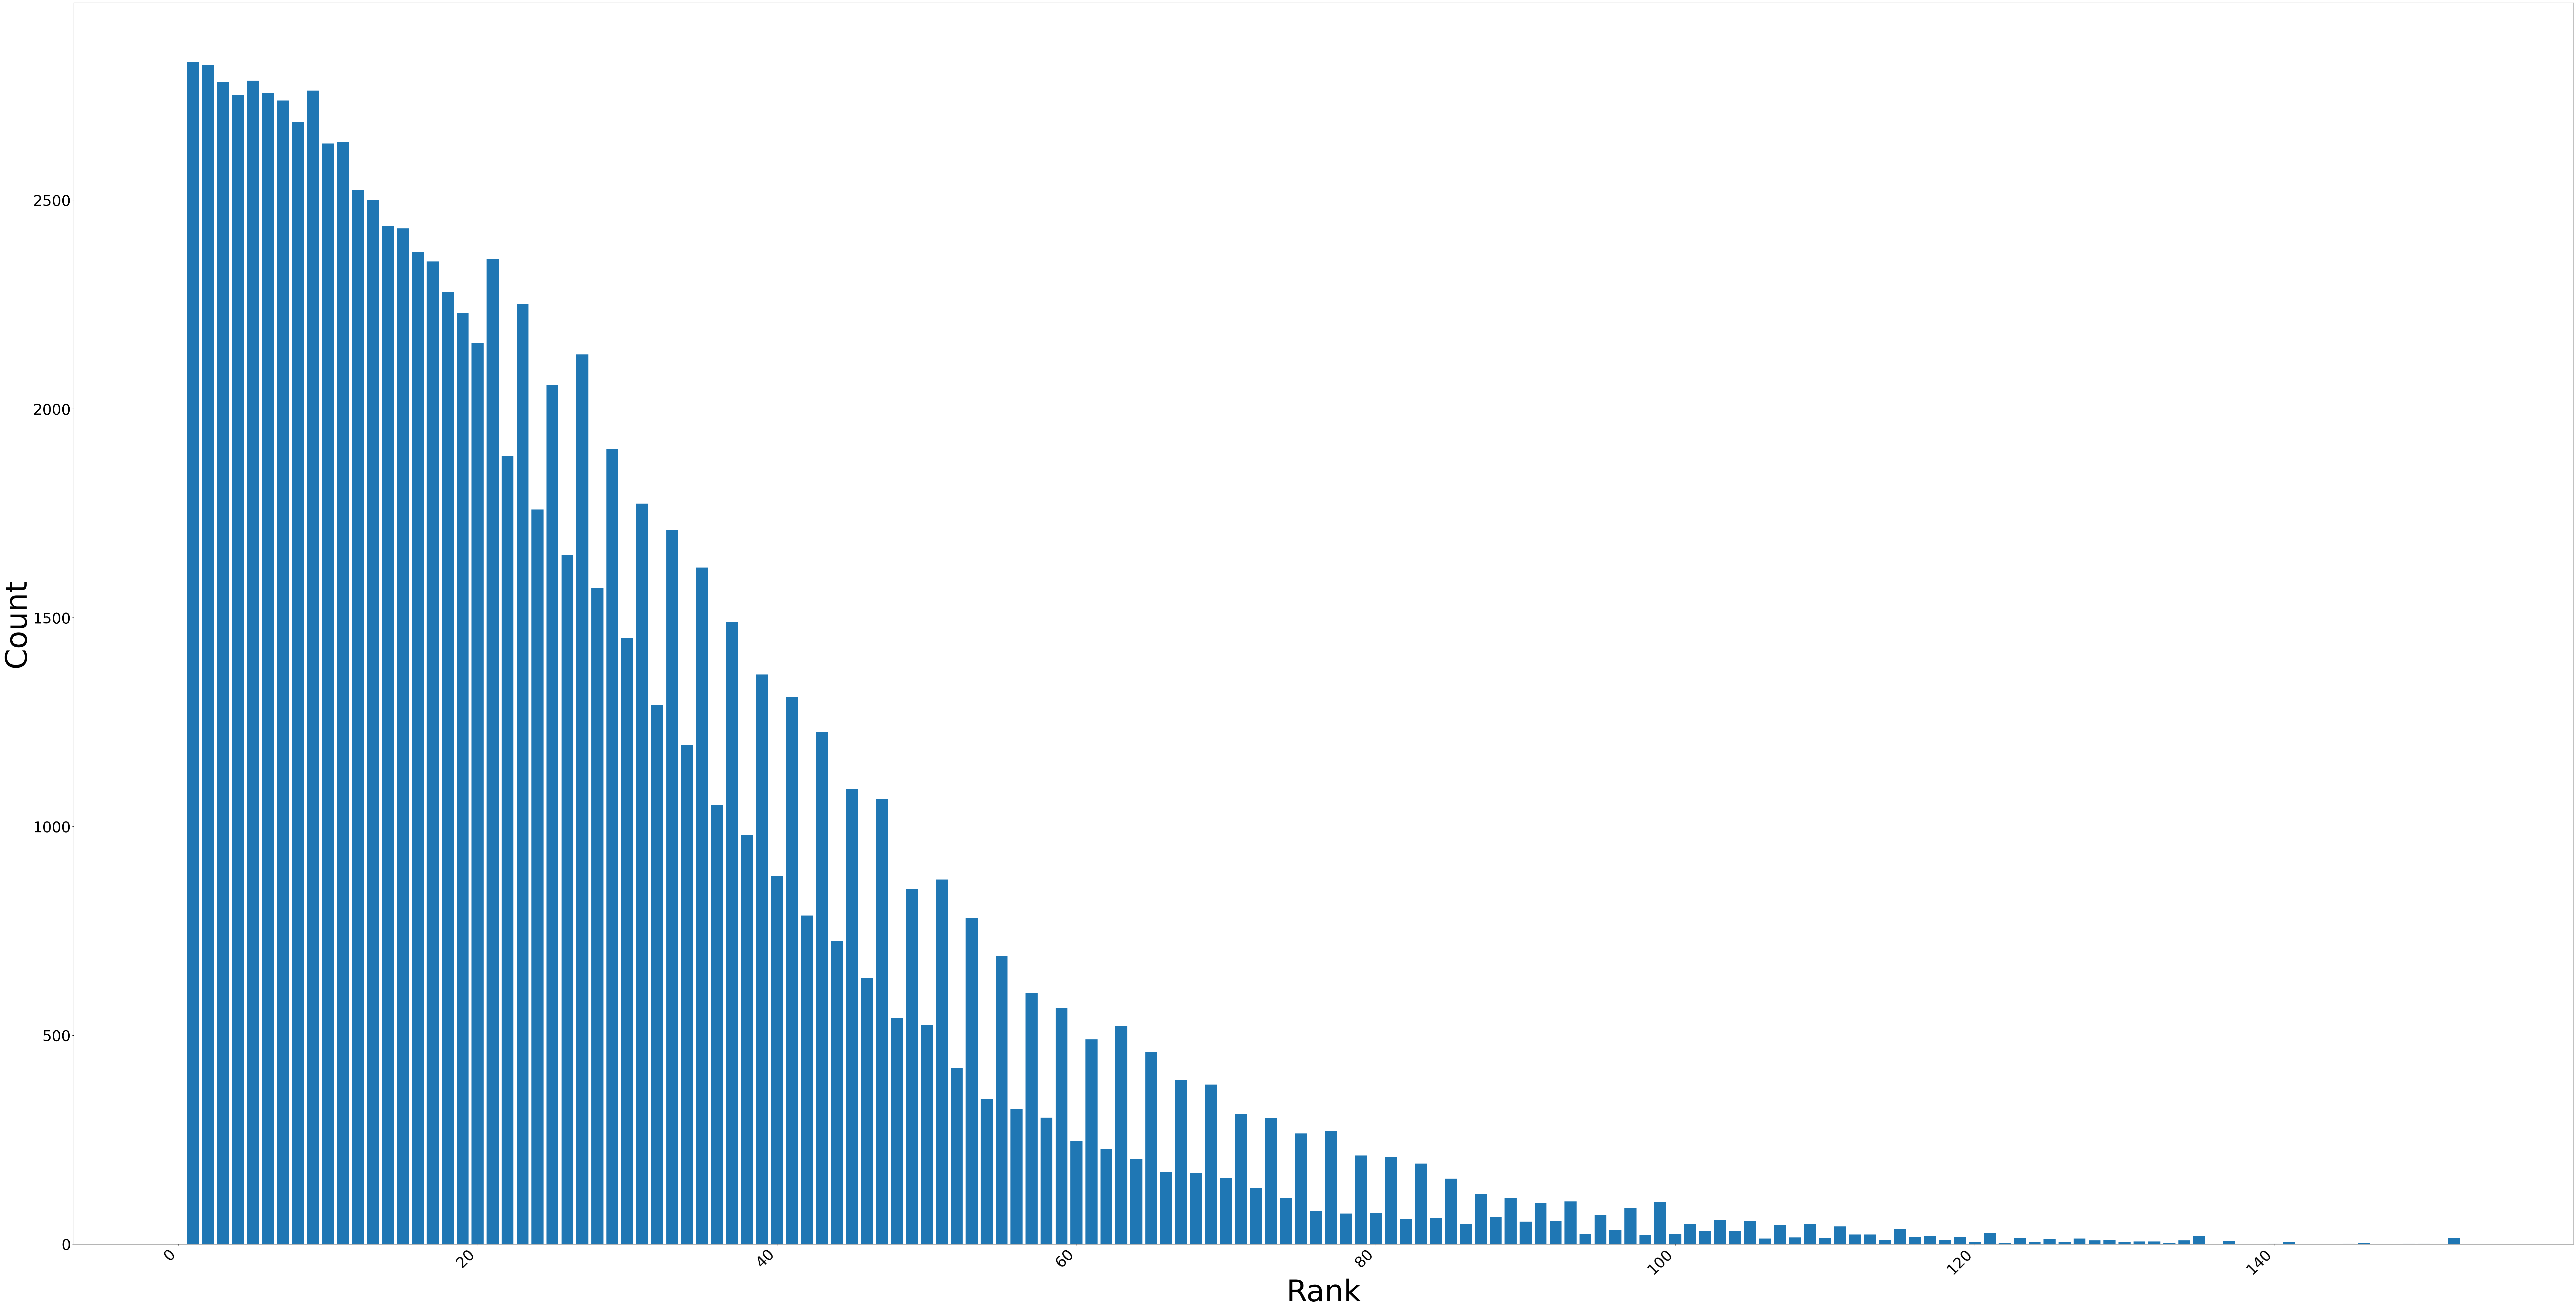

In [30]:


plt.figure(figsize=(120, 60))
plt.xlabel('Rank', fontsize=80)
plt.ylabel('Count', fontsize=80)
plt.xticks(rotation=45, ha='right', fontsize=40)
plt.yticks(fontsize=40)
plt.bar(newresults_info["rank"].value_counts().index, newresults_info["rank"].value_counts().values)

(array([9.800e+01, 1.780e+02, 2.910e+02, 3.247e+03, 7.324e+03, 8.287e+03,
        9.747e+03, 9.576e+03, 9.284e+03, 6.785e+03, 6.552e+03, 6.541e+03,
        6.127e+03, 5.785e+03, 5.236e+03, 4.571e+03, 3.735e+03, 3.108e+03,
        2.452e+03, 1.941e+03, 1.402e+03, 1.012e+03, 7.090e+02, 4.770e+02,
        2.870e+02, 1.970e+02, 1.240e+02, 5.800e+01, 4.200e+01, 1.200e+01,
        7.000e+00, 4.000e+00, 3.000e+00, 2.000e+00, 1.000e+00, 2.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([10.00078549, 11.0608959 , 12.12100631, 13.18111672, 14.24122713,
        15.30133754, 16.36144795, 17.42155836, 18.48166877, 19.54177918,
        20.60188959, 21.66200001, 22.72211042, 23.78222083, 24.84233124,
        25.90244165, 26.96255206, 28.02266247, 29.08277288, 30.14288329,
        31.2029937 , 32.26310411, 33.32321452, 34.38332493, 35.44343534,
        36.50354576, 37.56365617, 38.62376658, 39.68387699, 40.7439874 ,
        41.80409781, 42.86420822, 43.92431863, 44.98442904, 46.0

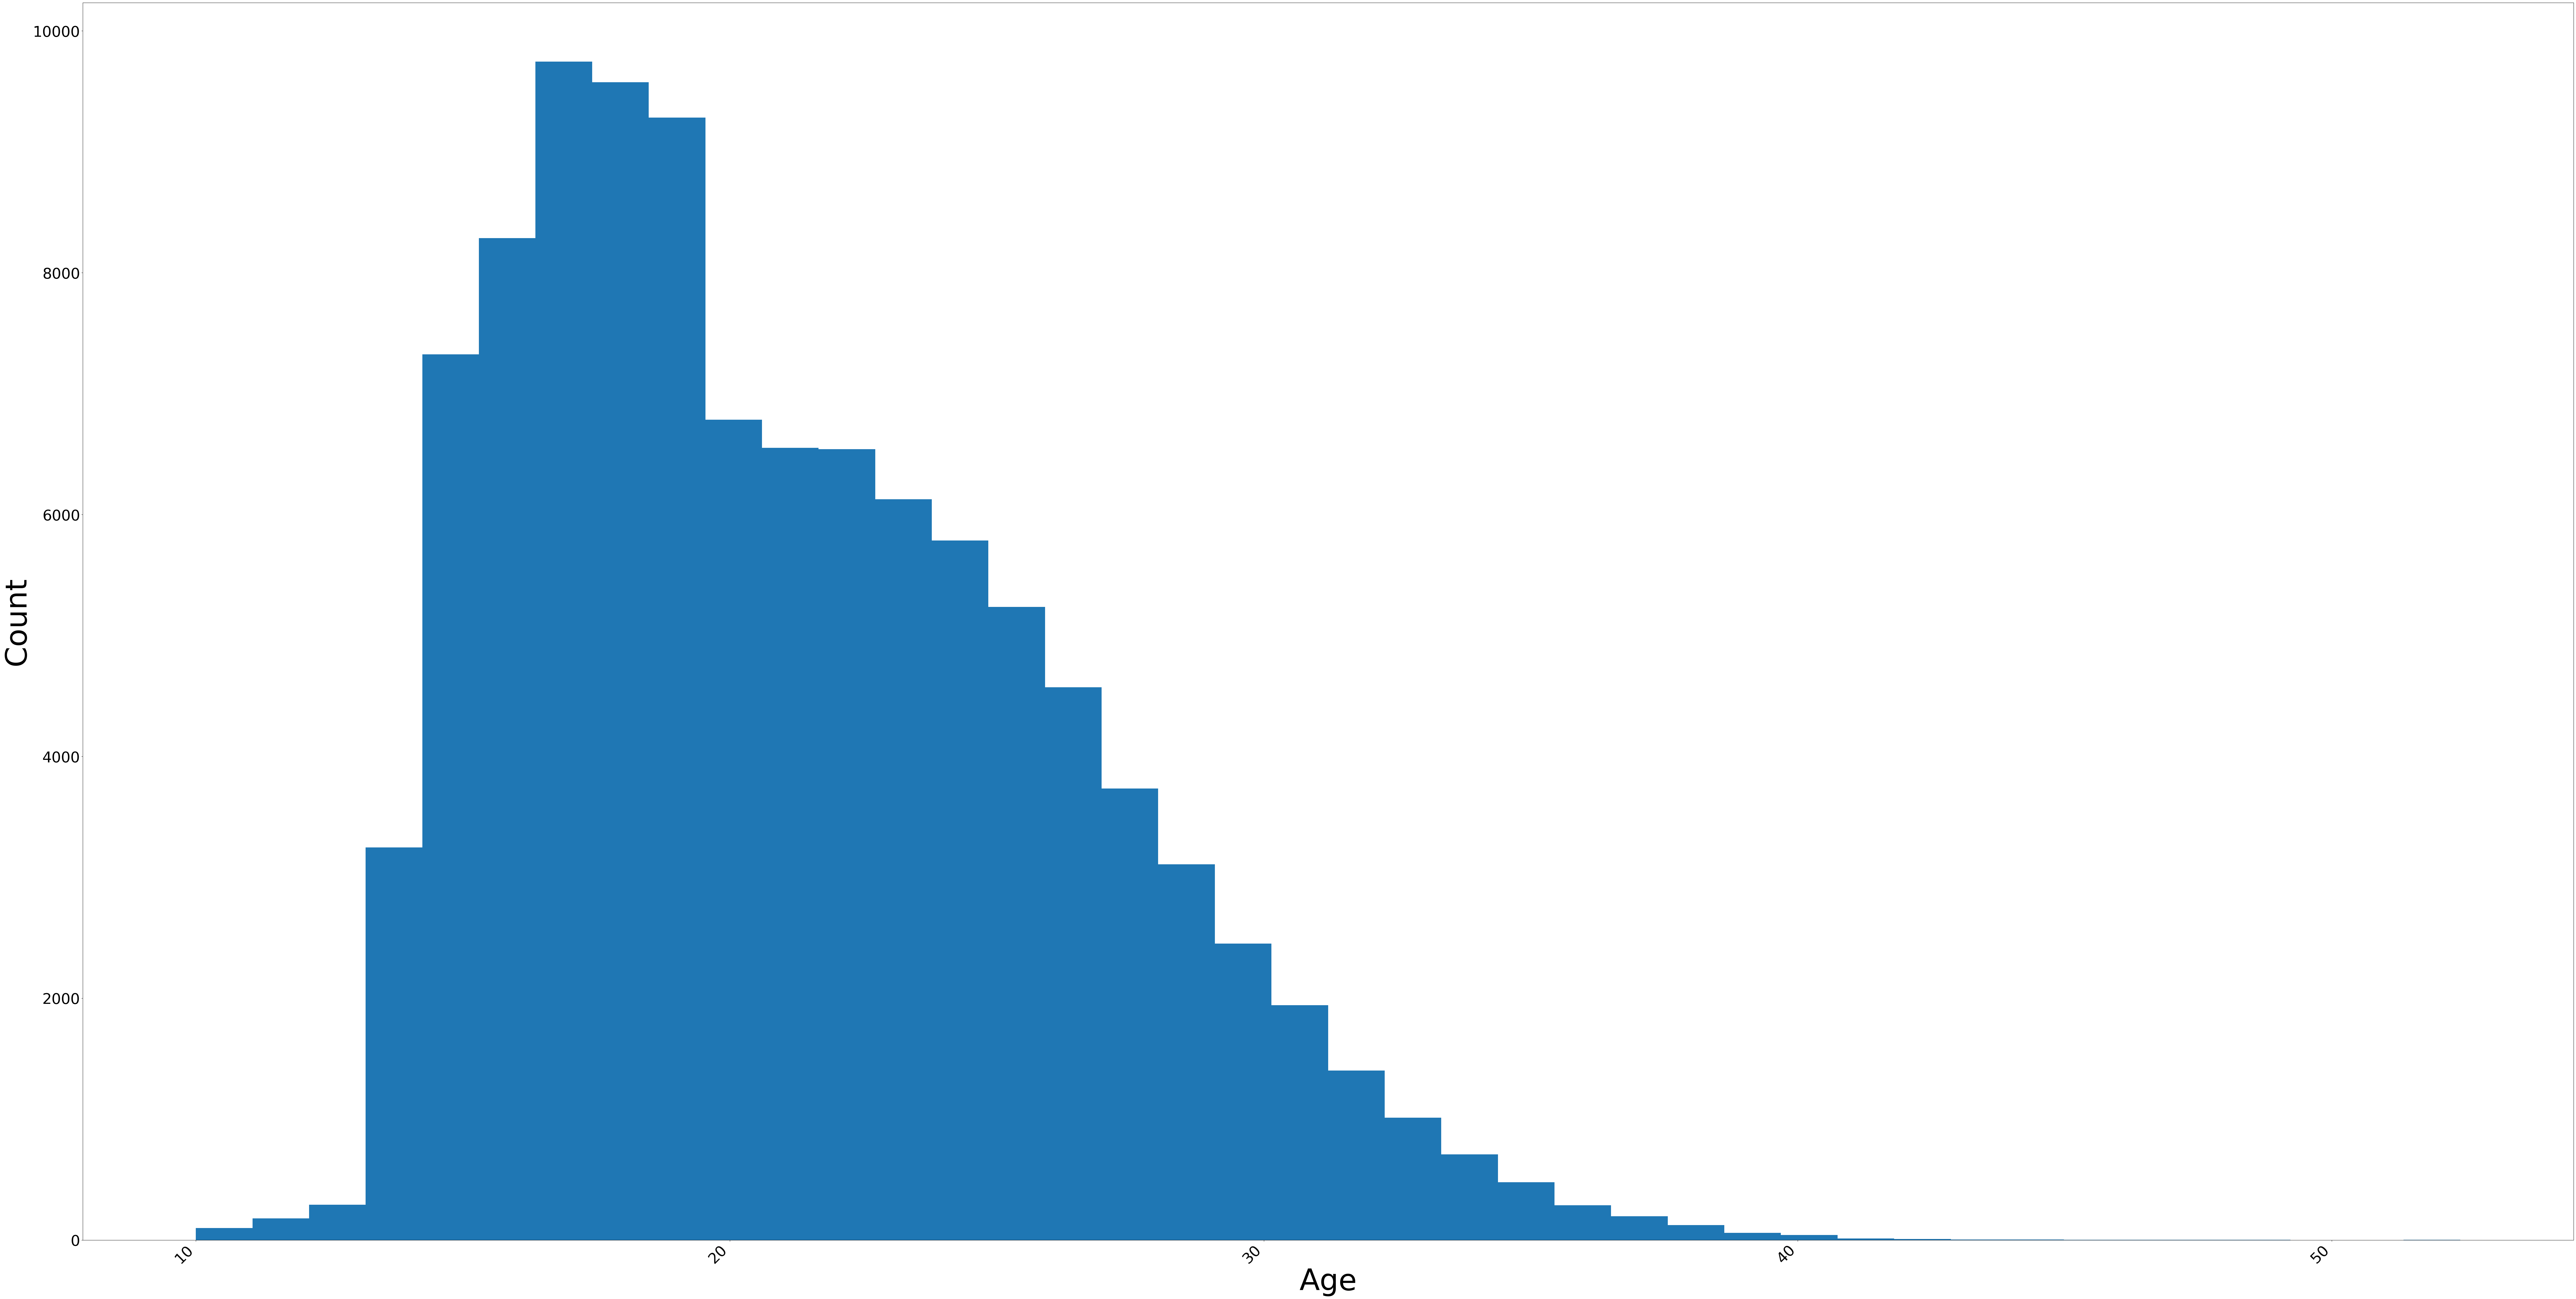

In [31]:
plt.figure(figsize=(120, 60))
plt.xlabel('Age', fontsize=80)
plt.ylabel('Count', fontsize=80)
plt.xticks(rotation=45, ha='right', fontsize=40)
plt.yticks(fontsize=40)
plt.hist(newresults_info["age_at_comp"], bins = 40)

In [32]:
import seaborn as sns
from sklearn.metrics import r2_score

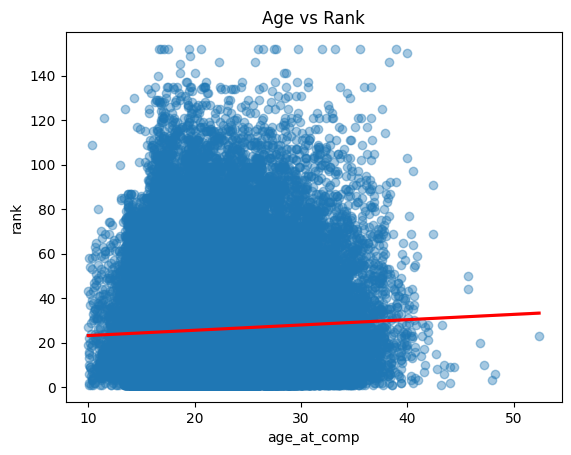

In [33]:
sns.regplot(x='age_at_comp', y='rank', data=newresults_info,  scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title('Age vs Rank')
plt.show()

In [34]:
r2 = r2_score(newresults_info['rank'], newresults_info['age_at_comp'])
print(r2)

-0.0818878783391428


In [35]:
athlete_df = newresults_info.groupby('athlete_id')[['gender_male', 'discipline_lead']].first()

pd.crosstab(athlete_df['gender_male'], athlete_df['discipline_lead'])



discipline_lead,False,True
gender_male,,
False,1887,2990
True,2951,4308


In [36]:
athlete_df1 = newresults_info.groupby('athlete_id')[['gender_male', 'discipline_boulder']].first()

pd.crosstab(athlete_df1['gender_male'], athlete_df1['discipline_boulder'])

discipline_boulder,False,True
gender_male,,
False,2990,1887
True,4308,2951


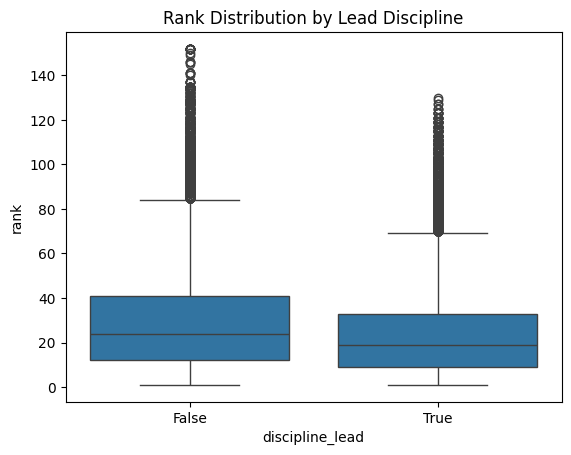

In [37]:
sns.boxplot(x='discipline_lead', y='rank', data=newresults_info)
plt.title('Rank Distribution by Lead Discipline')
plt.show()

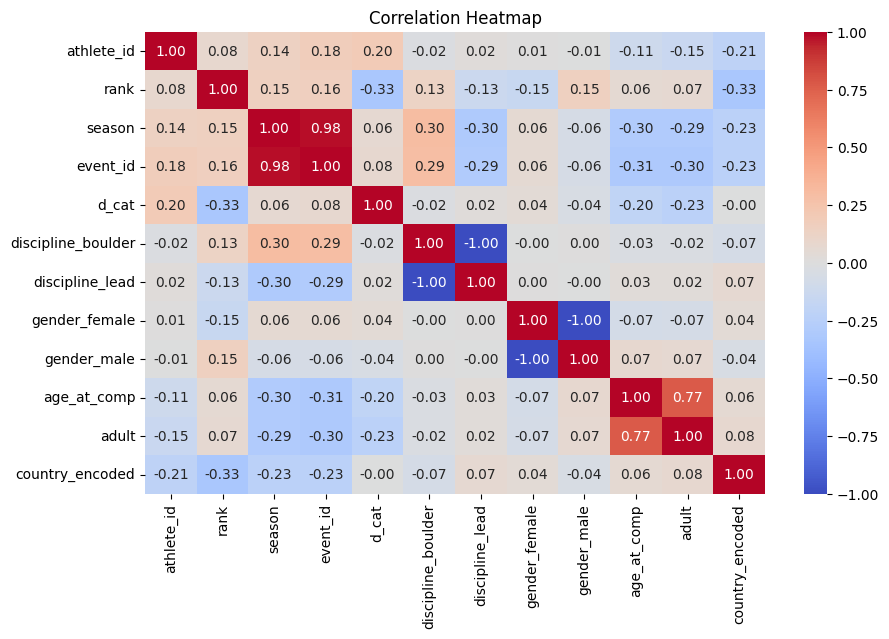

In [38]:
plt.figure(figsize=(10, 6))
sns.heatmap(newresults_info.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

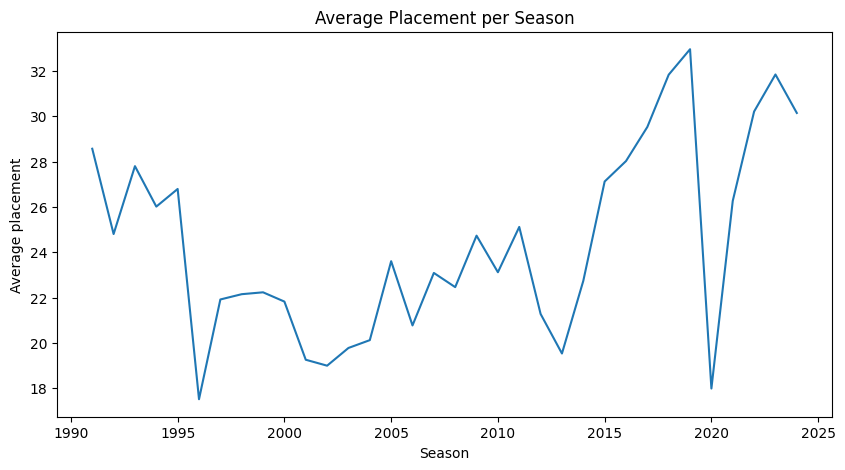

In [39]:

newresults_info.groupby('season')['rank'].mean().plot(figsize=(10,5))
plt.title('Average Placement per Season')
plt.ylabel('Average placement')
plt.xlabel('Season')
plt.show()

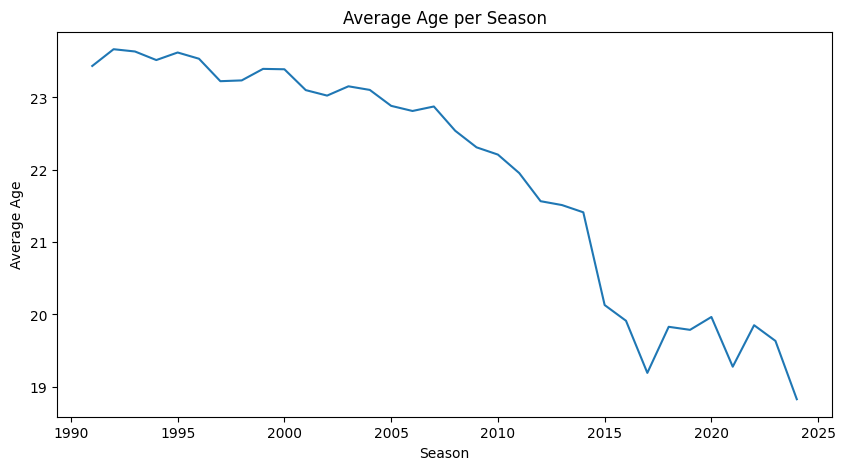

In [40]:
newresults_info.groupby('season')['age_at_comp'].mean().plot(figsize=(10,5))
plt.title('Average Age per Season')
plt.ylabel('Average Age')
plt.xlabel('Season')
plt.show()

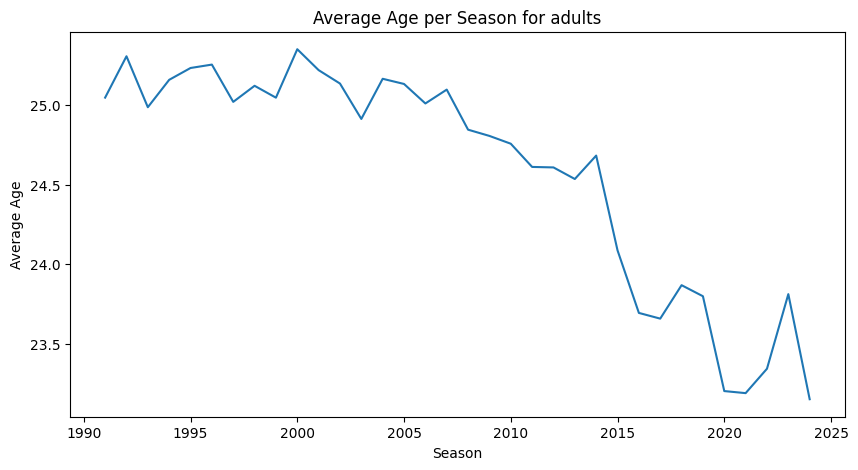

In [41]:
newresults_info[newresults_info['adult'] == True].groupby('season')['age_at_comp'].mean().plot(figsize=(10,5))
plt.title('Average Age per Season for adults')
plt.ylabel('Average Age')
plt.xlabel('Season')
plt.show()

a


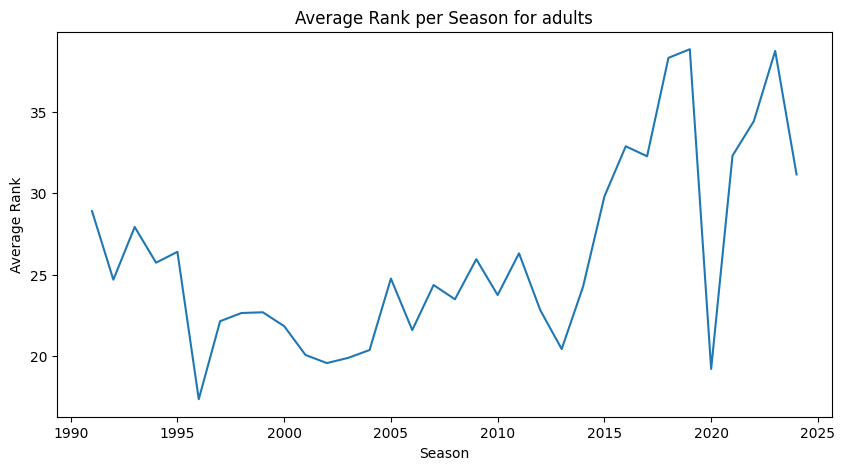

In [42]:

newresults_info[newresults_info['adult'] == True].groupby('season')['rank'].mean().plot(figsize=(10,5))
plt.title('Average Rank per Season for adults')
plt.ylabel('Average Rank')
plt.xlabel('Season')
plt.show()

In [43]:
def map_round(rank):
    if rank <= 3:
        return 3
    elif rank <= 8:
        return 2
    elif rank <= 24:
        return 1
    else:
        return 0


newresults_info['round_result'] = newresults_info['rank'].apply(map_round)

In [44]:
newresults_info.drop('rank', axis=1, inplace=True)


In [45]:
newresults_info.to_csv('output.csv')

### Model 1: Random forest

In [46]:
newresults_info.head()

,athlete_id,season,date,event_id,d_cat,discipline_boulder,discipline_lead,gender_female,gender_male,age_at_comp,adult,country_encoded,round_result
41,33,1994,1994-07-28,141,393,False,True,False,True,23.077344,True,4965,0
42,33,1994,1994-04-29,135,1,False,True,False,True,22.830938,True,4965,0
43,33,1993,1993-11-05,129,1,False,True,False,True,22.351814,True,4965,0
44,33,1993,1993-07-22,132,393,False,True,False,True,22.061602,True,4965,1
45,33,1993,1993-05-28,127,1,False,True,False,True,21.911020,True,4965,0


In [48]:
list1 = list(newresults_info.columns.values)

In [49]:
print(list1)

['athlete_id', 'season', 'date', 'event_id', 'd_cat', 'discipline_boulder', 'discipline_lead', 'gender_female', 'gender_male', 'age_at_comp', 'adult', 'country_encoded', 'round_result']


In [64]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


newresults_info['year'] = newresults_info['date'].dt.year
newresults_info['month'] = newresults_info['date'].dt.month
newresults_info['dayofyear'] = newresults_info['date'].dt.dayofyear


X = newresults_info.drop(columns=['date', 'round_result'])
y = newresults_info['round_result']



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns


scaler = StandardScaler()
X_train_scaled_numeric = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled_numeric = scaler.transform(X_test[numeric_cols])


X_train_scaled_numeric = pd.DataFrame(X_train_scaled_numeric,
                                      columns=numeric_cols,
                                      index=X_train.index)

X_test_scaled_numeric = pd.DataFrame(X_test_scaled_numeric,
                                     columns=numeric_cols,
                                     index=X_test.index)
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = X_train_scaled_numeric
X_test_scaled[numeric_cols] = X_test_scaled_numeric

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
clf_rf = RandomForestClassifier(class_weight = "balanced", n_estimators= 100, max_depth= None, max_features = "sqrt", min_samples_split= 50, random_state=32)
clf_rf.fit(X_train_scaled, y_train)

In [53]:
from sklearn.metrics import confusion_matrix

In [ ]:
y_pred_rf = clf_rf.predict(X_test_scaled)

#Evaluate the classifier
print("\nRandom Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}", '\n')
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

In [ ]:
newresults_info.head()

Feature Importance: Analyze the importance of each feature in making predictions by examining the feature importances attribute of the Random Forest model.

 You can access these by using the following:
#Get feature importances
importances = rf.feature_importances_

indices = np.argsort(importances)[::-1]

feature_names = df.columns[:-1]

Tuning Model Parameters

Parameters:

#Number of trees in the forest
n_estimators = 100     

#Maximum depth of the tree
max_depth = None       

#Minimum number of samples required to split an internal node
min_samples_split = 2  

#Number of features to consider when looking for the best split
max_features = 'sqrt'

Grid Search: Use grid search to systematically explore a range of hyperparameters and identify the combination that results in the best performance. Hyperparameters to tune include n_estimators, max_depth, min_samples_split, and max_features.

Cross-Validation: Employ cross-validation during grid search to ensure that the hyperparameter tuning process is robust and the results are not biased by a single train-test split.


In [52]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_grid = {
    'n_estimators': [300],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [2],

}



random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(),
    param_distributions=param_grid,
    n_iter=1,
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)


print("Best Parameters:", random_search.best_params_)
print("\nBest Estimator:", random_search.best_estimator_)

# Evaluate best model
best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)

print("\nTuned Random Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

In [ ]:
import matplotlib.pyplot as plt

# Get trained model importances
importances = best_rf.feature_importances_

# Get feature names from X_train (scaled version)
feature_names = X_train_scaled.columns

# Sort indices (largest → smallest)
indices = np.argsort(importances)[::-1]

# Create sorted table
sorted_features = pd.DataFrame({
    'Feature': feature_names[indices],
    'Importance': importances[indices]
})

print(sorted_features.head(20))  # show top 20

In [63]:
newresults_info = newresults_info.drop("d_cat", axis = 1)

KeyError: "['d_cat'] not found in axis"

### Model 2: XGboost

In [55]:
import xgboost as xgb

In [54]:
from xgboost import XGBClassifier


In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("XGBoost Accuracy:", acc)

In [ ]:
param_dist = {
    'n_estimators': [600, 800, 1000],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 1, 5],
}
xgb_clf = XGBClassifier(
    objective="multi:softprob",
    tree_method="hist",
    eval_metric="mlogloss"
)

random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=25,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
    random_state=42
)
random_search.fit(X_train, y_train)


In [ ]:
best_xgb = random_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

print("Best Params:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

In [65]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)


xgb_weighted = XGBClassifier(
    n_estimators=1000,
    reg_alpha=1.0,
    reg_lambda=2.0,
    min_child_weight=5,
    max_depth=6,
    subsample=0.7,
    colsample_bytree=0.7,
    learning_rate=0.03,



    gamma=1,
    tree_method='hist',
    eval_metric='mlogloss',
    objective='multi:softprob',
    num_class=4,
    early_stopping_rounds=30,
    n_jobs=-1,
    random_state=42
)


xgb_weighted.fit(
    X_train,
    y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],


    verbose=True
)


y_pred = xgb_weighted.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


y_pred = xgb_weighted.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

[0]	validation_0-mlogloss:1.38028
[1]	validation_0-mlogloss:1.37598
[2]	validation_0-mlogloss:1.37004
[3]	validation_0-mlogloss:1.36413
[4]	validation_0-mlogloss:1.35866
[5]	validation_0-mlogloss:1.35465
[6]	validation_0-mlogloss:1.34985
[7]	validation_0-mlogloss:1.34565
[8]	validation_0-mlogloss:1.34126
[9]	validation_0-mlogloss:1.33727
[10]	validation_0-mlogloss:1.33280
[11]	validation_0-mlogloss:1.32861
[12]	validation_0-mlogloss:1.32543
[13]	validation_0-mlogloss:1.32212
[14]	validation_0-mlogloss:1.31806
[15]	validation_0-mlogloss:1.31437
[16]	validation_0-mlogloss:1.31117
[17]	validation_0-mlogloss:1.30745
[18]	validation_0-mlogloss:1.30495
[19]	validation_0-mlogloss:1.30161
[20]	validation_0-mlogloss:1.29820
[21]	validation_0-mlogloss:1.29596
[22]	validation_0-mlogloss:1.29273
[23]	validation_0-mlogloss:1.28965
[24]	validation_0-mlogloss:1.28671
[25]	validation_0-mlogloss:1.28353
[26]	validation_0-mlogloss:1.28065
[27]	validation_0-mlogloss:1.27768
[28]	validation_0-mlogloss:1.2

a

In [ ]:
newresults_info.head()

In [59]:
import seaborn as sns

In [58]:
report = classification_report(y_test, y_pred, output_dict=True)

report1 = pd.DataFrame(report)
report1.drop("support", inplace = True)


In [ ]:
print(report1.columns)

In [ ]:
report1.rename(columns={'0': 'Qualified', '1': 'Semifinals', '2': 'Finals', '3': 'Podium'}, inplace = True)

In [ ]:
sns.heatmap(report1.T, annot = True)

In [ ]:
importances = xgb_weighted.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(importance_df.head(20))

In [69]:
model_data_assets = {
    'model': xgb_weighted,             # Your final trained model
    'scaler': scaler,                  # Your fitted StandardScaler
    'numeric_cols': numeric_cols.tolist(), # List of columns that need scaling
    'feature_columns': list(X.columns.values) # List of ALL features in order
}




pickle.dump(model_data_assets, open('model1.pkl', 'wb'))


In [68]:
X.columns

Index(['athlete_id', 'season', 'event_id', 'discipline_boulder',
       'discipline_lead', 'gender_female', 'gender_male', 'age_at_comp',
       'adult', 'country_encoded', 'year', 'month', 'dayofyear'],
      dtype='object')

In [ ]:
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'].head(20), importance_df['importance'].head(20))
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top Feature Importances")
plt.show()

In [61]:
import pickle

In [ ]:
pickle.dump(xgb_weighted, open('model.pkl', 'wb'))

a

In [60]:
newresults_info.head()

,athlete_id,season,date,event_id,d_cat,discipline_boulder,discipline_lead,gender_female,gender_male,age_at_comp,adult,country_encoded,round_result,year,month,dayofyear
41,33,1994,1994-07-28,141,393,False,True,False,True,23.077344,True,4965,0,1994,7,209
42,33,1994,1994-04-29,135,1,False,True,False,True,22.830938,True,4965,0,1994,4,119
43,33,1993,1993-11-05,129,1,False,True,False,True,22.351814,True,4965,0,1993,11,309
44,33,1993,1993-07-22,132,393,False,True,False,True,22.061602,True,4965,1,1993,7,203
45,33,1993,1993-05-28,127,1,False,True,False,True,21.911020,True,4965,0,1993,5,148


In [ ]:
df = newresults_info.copy()
df['date'] = pd.to_datetime(df['date'])

# Make finals? (1 = yes, 0 = no)
df['finals_flag'] = (df['round_result'] >= 2).astype(int)
print(df['finals_flag'].value_counts())

In [ ]:
cutoff = pd.Timestamp("2020-01-01")

train1 = df[df['date'] < cutoff]
test1  = df[df['date'] >= cutoff]

print("Train shape:", train1.shape)
print("Test shape:", test1.shape)

In [ ]:
drop_cols = ['date', 'round_result', 'finals_flag', 'firstname', 'lastname']
feature_cols = [c for c in df.columns if c not in drop_cols]

X_train3 = train1[feature_cols].copy()
y_train3 = train1['finals_flag']

X_test3  = test1[feature_cols].copy()
y_test3  = test1['finals_flag']

In [ ]:
numeric_cols = X_train3.select_dtypes(include=['int64','float64']).columns

scaler = StandardScaler()

X_train3[numeric_cols] = scaler.fit_transform(X_train3[numeric_cols])

X_test3[numeric_cols] = scaler.transform(X_test3[numeric_cols])

In [ ]:
sample_weights1 = compute_sample_weight(class_weight='balanced', y=y_train3)


In [ ]:
from sklearn.metrics import f1_score

In [ ]:
probs = xgb_weighted.predict_proba(X_test3)[:,1]

best_t = 0
best_f1 = 0

for t in [i/100 for i in range(1,50)]:
    preds = (probs >= t).astype(int)
    f1 = f1_score(y_test3, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(best_t, best_f1)

In [ ]:
xgb_recall = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',

    n_estimators=1500,
    max_depth=7,
    min_child_weight=3,

    learning_rate=0.06,


    subsample=0.85,
    colsample_bytree=0.85,

    scale_pos_weight=(len(y_train3) - y_train3.sum()) / y_train3.sum(),

    gamma=0.5,
    reg_alpha=0.5,
    reg_lambda=1.5,

   tree_method='hist',
   n_jobs=-1,
   random_state=42
)

xgb_recall.fit(
    X_train3,
    y_train3,
    sample_weight=sample_weights1,
    eval_set=[(X_test3, y_test3)],
    verbose=True
)



In [ ]:
from sklearn.metrics import f1_score

In [ ]:

y_pred = (xgb_weighted.predict_proba(X_test3)[:,1] >= 0.5).astype(int)

print("\n=== FINAL EVAL ON 2026+ ===")
print("Accuracy:", accuracy_score(y_test3, y_pred))
print("Weighted F1:", f1_score(y_test3, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test3, y_pred))
print("\nClassification Report:\n", classification_report(y_test3, y_pred))


In [ ]:
import numpy as np
from sklearn.metrics import f1_score, precision_recall_fscore_support

# Get probabilities
probs = xgb_weighted.predict_proba(X_test3)[:, 1]

thresholds = np.linspace(0.01, 0.50, 50)
best_t = 0
best_f1 = 0

for t in thresholds:
    preds = (probs >= t).astype(int)
    f1 = f1_score(y_test3, preds, average='binary')
    if f1 > best_f1:
        best_f1 = f1
        best_t = t


# Evaluate using this threshold
y_pred_opt = (probs >= best_t).astype(int)

prec, rec, f1, _ = precision_recall_fscore_support(
    y_test3, y_pred_opt, average='binary'
)

print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)
print("Accuracy:", accuracy_score(y_test3,  y_pred_opt))
print("Weighted F1:", f1_score(y_test3,  y_pred_opt, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test3, y_pred_opt))
print("\nClassification Report:\n", classification_report(y_test3, y_pred_opt))

a